# 中美科技与金融股风险收益特征分析

## 项目背景
本项目旨在分析中美两地代表性股票（科技股与金融股）的收益率特征、
波动性表现，以及它们相对各自市场大盘指数的风险敏感度（beta），
并探讨中美股票之间的相关性，为资产配置提供参考视角。

## 数据说明
- **时间区间**：2025-01-01 至 2026-01-01
- **数据来源**：Yahoo Finance（通过 yfinance 库获取）
- **分析标的**：
  - AAPL（苹果，美股科技）
  - MSFT（微软，美股科技）
  - 600519.SS（贵州茅台，A股消费）
  - 000001.SZ（平安银行，A股金融）
  - ^GSPC（标普500，美股大盘基准）

## 分析方法
1. 收益率与波动率计算
2. 移动平均线趋势观察
3. 多股票相关性分析（热力图）
4. 线性回归分析个股beta系数
5. 残差分析检验模型可靠性

In [53]:
import pandas as pd
import sqlite3 
import yfinance as yf

def get_stock_data(ticker,start_date,end_date):
    data = yf.download(ticker,start=start_date,end=end_date)
    data.columns = data.columns.get_level_values(0)
    return data


In [54]:
# 定义分析标的
tickers = {
    'AAPL': 'AAPL',
    'MSFT': 'MSFT',
    '600519_SS': '600519.SS',
    '000001_SZ': '000001.SZ',
    'GSPC': '^GSPC'
}

start_date = '2025-01-01'
end_date = '2026-01-01'

In [55]:
# 批量获取并存入数据库
conn = sqlite3.connect('stock_data.db')

for table_name, ticker in tickers.items():
    data = get_stock_data(ticker,start_date,end_date)
    data.to_sql(table_name,conn,if_exists='replace')
    print(f'{table_name}获取完成，共{len(data)}条数据')

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/yfinance/scrapers/history.py:472: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[*********************100%***********************]  1 of 1 completed
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/yfinance/scrapers/history.py:472: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[*********************100%***********************]  1 of 1 completed
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/yfinance/scrapers/history.py:472: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype e

AAPL获取完成，共250条数据
MSFT获取完成，共250条数据
600519_SS获取完成，共243条数据
000001_SZ获取完成，共243条数据
GSPC获取完成，共250条数据


In [56]:
# 从数据库读取数据并计算日收益率
table_names = ['AAPL', 'MSFT', '600519_SS', '000001_SZ', 'GSPC']
stock_returns = {}

for name in table_names:
    data = pd.read_sql(f'select Date, CLose from "{name}"',conn)
    data['return'] = data['Close'].pct_change()
    stock_returns[name] = data
    print(f'{name}收益率计算完成，共{len(data)}条记录')


AAPL收益率计算完成，共250条记录
MSFT收益率计算完成，共250条记录
600519_SS收益率计算完成，共243条记录
000001_SZ收益率计算完成，共243条记录
GSPC收益率计算完成，共250条记录


In [57]:
merged = None
for name, data in stock_returns.items():
    data_rename = data[['Date','return']].rename(columns={'return' : f'return_{name}'})
    if merged is None:
        merged = data_rename
    else:
        merged = pd.merge(merged,data_rename,on='Date')
merged = merged.dropna()                

In [58]:
print(f'合并后共有 {len(merged)} 条记录')
print(f'时间范围：{merged["Date"].min()} 至 {merged["Date"].max()}')
merged.head()

合并后共有 232 条记录
时间范围：2025-01-03 00:00:00 至 2025-12-31 00:00:00


,Date,return_AAPL,return_MSFT,return_600519_SS,return_000001_SZ,return_GSPC
1,2025-01-03 00:00:00,-0.002009,0.011396,-0.008737,-0.004375,0.012596
2,2025-01-06 00:00:00,0.006739,0.010630,-0.023729,0.005272,0.005538
3,2025-01-07 00:00:00,-0.011388,-0.012808,0.000139,0.006119,-0.011104
4,2025-01-08 00:00:00,0.002023,0.005185,0.001597,-0.000869,0.001560
5,2025-01-10 00:00:00,-0.024104,-0.013214,-0.005540,-0.008772,-0.015412


In [59]:
return_cols = []
for col in merged.columns:
    if col.startswith('return_'):
        return_cols.append(col)

summary = merged[return_cols].describe()
print(summary)

       return_AAPL  return_MSFT  return_600519_SS  return_000001_SZ  \
count   232.000000   232.000000        232.000000        232.000000   
mean      0.001166     0.000635         -0.000148          0.000179   
std       0.020022     0.013955          0.010759          0.009948   
min      -0.092456    -0.036606         -0.043904         -0.056438   
25%      -0.006449    -0.005918         -0.005374         -0.005629   
50%       0.000746     0.000609         -0.000658          0.000000   
75%       0.007597     0.006167          0.005217          0.005324   
max       0.153289     0.101337          0.058682          0.032338   

       return_GSPC  
count   232.000000  
mean      0.000854  
std       0.011483  
min      -0.048396  
25%      -0.003481  
50%       0.001294  
75%       0.005604  
max       0.095154  


In [60]:
volatility = merged.drop(columns=['Date']).std()
print(volatility)

return_AAPL         0.020022
return_MSFT         0.013955
return_600519_SS    0.010759
return_000001_SZ    0.009948
return_GSPC         0.011483
dtype: float64


In [61]:
aapl_price = pd.read_sql("SELECT Date, Close FROM AAPL", conn)
aapl_price['Date'] = pd.to_datetime(aapl_price['Date'])
aapl_price['MA20'] = aapl_price['Close'].rolling(window=20).mean()
aapl_price['MA60'] = aapl_price['Close'].rolling(window=60).mean()


In [62]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False


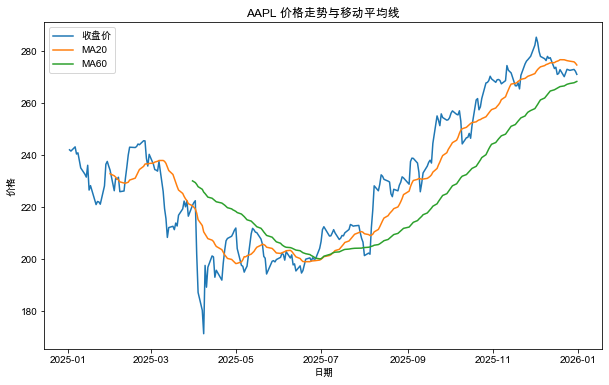

In [63]:
fig,ax = plt.subplots(figsize=(10, 6))
ax.plot(aapl_price['Date'],aapl_price['Close'], label='收盘价')
ax.plot(aapl_price['Date'],aapl_price['MA20'], label='MA20')
ax.plot(aapl_price['Date'],aapl_price['MA60'], label='MA60')
ax.set_xlabel('日期')
ax.set_ylabel('价格')
ax.set_title('AAPL 价格走势与移动平均线')
ax.legend()
plt.show()

In [64]:
import seaborn as sns

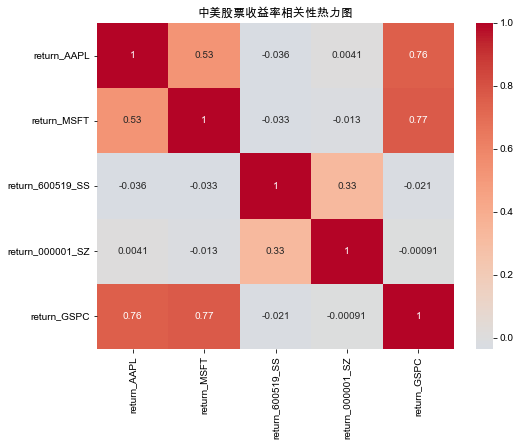

In [65]:
corr = merged.drop(columns=['Date']).corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr,annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('中美股票收益率相关性热力图')
plt.show()

In [66]:
#回归分析
import statsmodels.api as sm

In [67]:
x = merged['return_GSPC']
y = merged['return_MSFT']
x = sm.add_constant(x)
model = sm.OLS(y,x)
result = model.fit()
print(result.summary())



                            OLS Regression Results                            
Dep. Variable:            return_MSFT   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.590
Method:                 Least Squares   F-statistic:                     333.4
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.21e-46
Time:                        14:36:13   Log-Likelihood:                 766.34
No. Observations:                 232   AIC:                            -1529.
Df Residuals:                     230   BIC:                            -1522.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0002      0.001     -0.277      

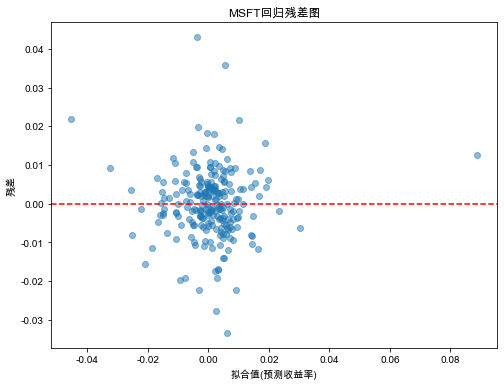

In [68]:
#残差分析
fitted_msft = result.fittedvalues
residuals_msft = result.resid
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(fitted_msft, residuals_msft, alpha=0.5)
ax.axhline(y=0, color='red', linestyle='--')
ax.set_xlabel('拟合值(预测收益率)')
ax.set_ylabel('残差')
ax.set_title('MSFT回归残差图')
plt.show()